# Written text as operational data

Written text is one type of data

### Why people write?

 - To communicate: their thoughts, feelings, urgency, needs, information

### Why people communicate?

1. To express emotions
1. To share information
1. To enable or elicit an action
1. ...

### We will use written text for the purpose other than 
1. To experience emotion
1. To learn something the author intended us to learn
1. To do what the author intended us to do

### Instead, we will use written text to recognize who wrote it
 - By calculating and comparing word frequencies in written documents
 
See, for example, likely fictional story https://medium.com/@amuse/how-the-nsa-caught-satoshi-nakamoto-868affcef595

### Example 1. Dictionaries in python (associative arrays)

Plot the frequency distribution of words on a web page.

In [1]:
import requests, re
# re is a module for regular expressions: to detect various combinations of characters
import operator

# Start from a simple document
r = requests .get('http://eecs.utk.edu')

# What comes back includes headers and other HTTP stuff, get just the body of the response
t = r.text

# obtain words by splitting a string using as separator one or more (+) space/like characters (\s) 
wds = re.split('\s+',t)

# now populate a dictionary (wf)
wf = {}
for w in wds:
    if w in wf: wf [w] = wf [w] + 1
    else:  wf[w] = 1

# dictionaries can not be sorted, so lets get a sorted *list*        
wfs = sorted (wf .items(), key = operator .itemgetter (1), reverse=True)   

# lets just have no more than 15 words 
ml = min(len(wfs),15)
for i in range(1,ml,1):
    print (wfs[i][0]+"\t"+str(wfs[i][1]))  

class="menu-item	63
menu-item-type-post_type	61
menu-item-object-page	61
<div	47
</div>	44
and	36
<a	29
-->	26
/>	26
of	25
<link	19
<!--	18
0	18
H.	17


### Example 2

Lots of markup in the output, lets remove it --- 

use BeautifulSoup and nltk modules and practice some regular expressions.

In [4]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /home/dkim68/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [20]:
import requests, re, nltk
from bs4 import BeautifulSoup
from nltk import clean_html
from collections import Counter
import operator

# we may not care about the usage of stop words
stop_words = nltk.corpus.stopwords.words('english') + [
 'ut', '\'re','.', ',', '--', '\'s', '?', ')', '(', ':', '\'',
 '\"', '-', '}', '{', '&', '|', u'\u2014' ]

# We most likely would like to remove html markup
def cleanHtml (html):
    from bs4 import BeautifulSoup
    soup = BeautifulSoup(html, 'html.parser')
    return soup .get_text()

# We also want to remove special characters, quotes, etc. from each word
def cleanWord (w):
    # r in r'[.,"\']' tells to treat \ as a regular character 
    # but we need to escape ' with \'
    # any character between the brackets [] is to be removed 
    wn = re.sub('[,"\.\'&\|:@>*;/=“”‘’]', "", w)
    # get rid of numbers
    return re.sub('^[0-9\.]*$', "", wn)
       
# define a function to get text/clean/calculate frequency
def get_wf (URL):
    # first get the web page
    r = requests .get(URL)
    
    # Now clean
    # remove html markup
    t = cleanHtml (r .text) .lower()
    
    # split string into an array of words using any sequence of spaces "\s+" 
    wds = re .split('\s+',t)
    
    # remove periods, commas, etc stuck to the edges of words
    for i in range(len(wds)):
        wds [i] = cleanWord (wds [i])
    
    # If satisfied with results, lets go to the next step: calculate frequencies
    # We can write a loop to create a dictionary, but 
    # there is a special function for everything in python
    # in particular for counting frequencies (like function table() in R)
    wf = Counter (wds)
    
    # Remove stop words from the dictionary wf
    for k in stop_words:
        wf. pop(k, None)
        
    #how many regular words in the document?
    tw = 0
    for w in wf:
       tw += wf[w] 
        
    
    # Get ordered list
    wfs = sorted (wf .items(), key = operator.itemgetter(1), reverse=True)
    ml = min(len(wfs),15)

    #Reverse the list because barh plots items from the bottom
    return (wfs [ 0:ml ] [::-1], tw)
        
# Now populate two lists    
(wf_ee, tw_ee) = get_wf('https://www.gutenberg.org/cache/epub/1342/pg1342.txt')
(wf_bu, tw_bu) = get_wf('https://www.gutenberg.org/cache/epub/158/pg158.txt')

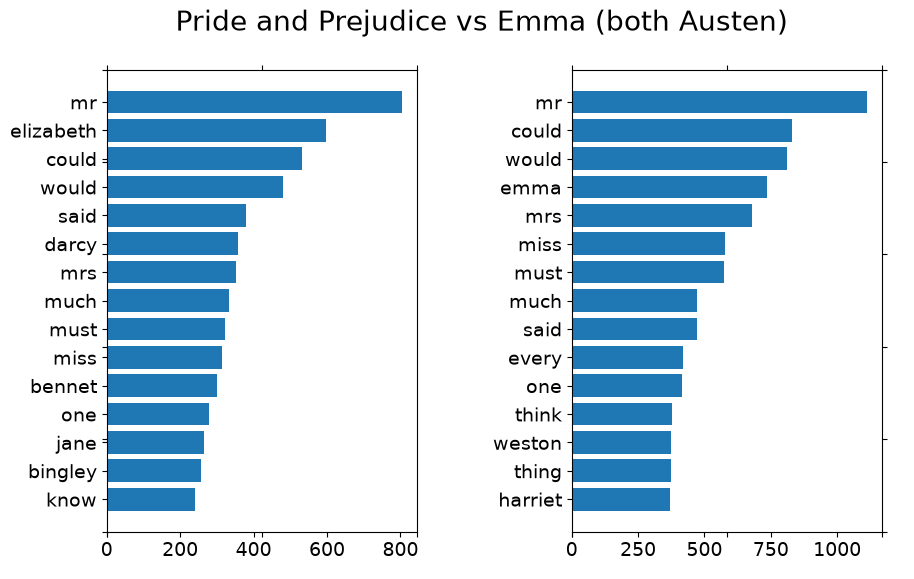

In [21]:
#Plot the results: are there striking differences in language?
import numpy as np
import pylab
import matplotlib.pyplot as plt

%matplotlib inline
def plotTwoLists (wf_ee, wf_bu, title):
    f = plt.figure (figsize=(10, 6))
    # this is painfully tedious....
    f .suptitle (title, fontsize=20)
    ax = f.add_subplot(111)
    ax .spines ['top'] .set_color ('none')
    ax .spines ['bottom'] .set_color ('none')
    ax .spines ['left'] .set_color ('none')
    ax .spines ['right'] .set_color ('none')
    ax .tick_params (labelcolor='w', top='off', bottom='off', left='off', right='off', labelsize=20)

    # Create two subplots, this is the first one
    ax1 = f .add_subplot (121)
    plt .subplots_adjust (wspace=.5)

    pos = np .arange (len(wf_ee)) 
    ax1 .tick_params (axis='both', which='major', labelsize=14)
    pylab .yticks (pos, [ x [0] for x in wf_ee ])
    ax1 .barh (range(len(wf_ee)), [ x [1] for x in wf_ee ], align='center')

    ax2 = f .add_subplot (122)
    ax2 .tick_params (axis='both', which='major', labelsize=14)
    pos = np .arange (len(wf_bu)) 
    pylab .yticks (pos, [ x [0] for x in wf_bu ])
    ax2 .barh (range (len(wf_bu)), [ x [1] for x in wf_bu ], align='center')

plotTwoLists (wf_ee, wf_bu, 'Pride and Prejudice vs Emma (both Austen)')

In [22]:
#In case Project gutenberg is blocked you can download text to your laptop and copy to the docker container via scp
#Assuming the file name you copy is pg4680.txt here is how you change the script
# Please note the option errors='replace'
# without it python invariably runs into unicode errors
f = open ('pg4680.txt', 'r', encoding="ascii", errors='replace')
    
# What comes back includes headers and other HTTP stuff, get just the body of the response
t = f.read()

# obtain words by splitting a string using as separator one or more (+) space/like characters (\s) 
wds = re.split('\s+',t)

# now populate a dictionary (wf)
wf = {}
for w in wds:
    if w in wf: wf [w] = wf [w] + 1
    else:  wf [w] = 1

# dictionaries can not be sorted, so lets get a sorted *list*        
wfs = sorted (wf .items(), key = operator .itemgetter (1), reverse=True)   

# lets just have no more than 15 words 
ml = min(len(wfs),15)
for i in range(1,ml,1):
    print (wfs[i][0]+"\t"+str(wfs[i][1]))  

and	2836
of	2676
to	2646
a	2217
in	1422
his	1205
he	928
that	920
was	823
for	798
with	797
as	672
I	505
you	497


# Assignment 1

1. Compare word frequencies between two works of a single author.
1. Compare word frequencies between works of two authors.
1. Are there some words preferred by one author but used less frequently by another author?

Extra credit

1. The frequency of a specific word, e.g., "would" should follow a binomial distribution (each regular word in a document is a trial and with probability p that word is "would". The estimate for p is N("would")/N(regular word)). Do these binomial distributions for your chosen word differ significantly between books of the same author or between authors? 

Project Gutenberg is a good source of for fiction and non-fiction.

E.g below are two most popular books from Project Gutenberg:
- Pride and Prejudice at http://www.gutenberg.org/ebooks/1342.txt.utf-8
- Adventures of Huckleberry Finn at http://www.gutenberg.org/ebooks/76.txt.utf-8

In [23]:
import requests, re, nltk
#In case your text is not on Project Gutenberg but at some other URL
#http://www.fullbooks.com/Our-World-or-The-Slaveholders-Daughter2.html
# that contains 12 parts
t = ""
for i in range(2,13):
  r = requests .get('http://www.fullbooks.com/Our-World-or-The-Slaveholders-Daughter' + str(i) + '.html')
  t = t + r.text

In [24]:
len(t)

1323653

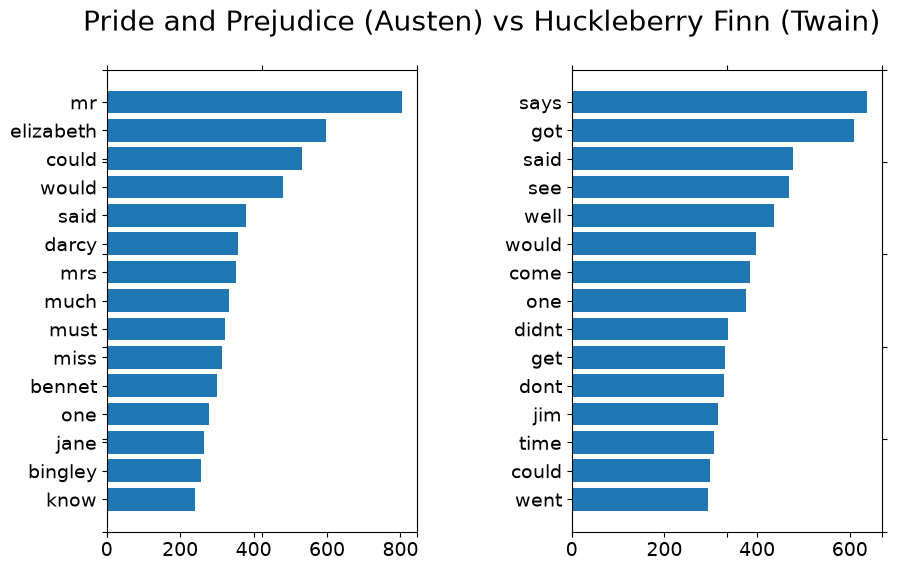

In [25]:
# Huckleberry Finn (Twain) for the cross-author comparison
(wf_hf, tw_hf) = get_wf('https://www.gutenberg.org/cache/epub/76/pg76.txt')
plotTwoLists(wf_ee, wf_hf, 'Pride and Prejudice (Austen) vs Huckleberry Finn (Twain)')

total words: 60451 75280 55604


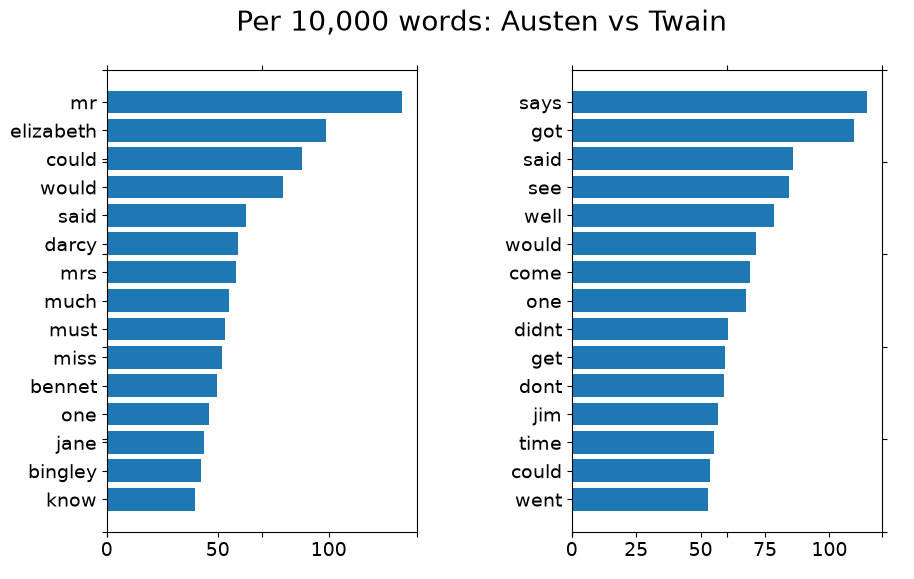

In [26]:
def normalize(wf, tw, per=10000):
    return [(w, c * per / tw) for w, c in wf]

print('total words:', tw_ee, tw_bu, tw_hf)
plotTwoLists(normalize(wf_ee, tw_ee), normalize(wf_hf, tw_hf),
             'Per 10,000 words: Austen vs Twain')

In [27]:
def get_wf_all(URL):
    r = requests.get(URL)
    t = cleanHtml(r.text).lower()
    wds = [cleanWord(w) for w in re.split('\s+', t)]
    wf = Counter(wds)
    for k in stop_words:
        wf.pop(k, None)
    wf.pop('', None)
    return wf, sum(wf.values())

all_ee, n_ee = get_wf_all('https://www.gutenberg.org/cache/epub/1342/pg1342.txt')
all_bu, n_bu = get_wf_all('https://www.gutenberg.org/cache/epub/158/pg158.txt')
all_hf, n_hf = get_wf_all('https://www.gutenberg.org/cache/epub/76/pg76.txt')

def preferred(a, na, b, nb, min_count=25, n=15):
    out = []
    for w in set(a) | set(b):
        ca, cb = a.get(w, 0), b.get(w, 0)
        if ca + cb < min_count:      # ignore rare words, they are noise
            continue
        ra, rb = ca * 10000.0 / na, cb * 10000.0 / nb
        out.append((w, ra - rb, ra, rb))
    out.sort(key=operator.itemgetter(1))
    return out[-n:][::-1], out[:n]

austen, twain = preferred(all_ee, n_ee, all_hf, n_hf)
print('Austen uses more (per 10k):')
for w, d, ra, rb in austen:
    print('  %-14s %7.1f vs %7.1f' % (w, ra, rb))
print('\nTwain uses more (per 10k):')
for w, d, ra, rb in twain:
    print('  %-14s %7.1f vs %7.1f' % (w, ra, rb))

Austen uses more (per 10k):
  mr               133.4 vs     3.8
  elizabeth         98.9 vs     0.0
  darcy             59.4 vs     0.0
  mrs               58.6 vs     1.4
  bennet            49.9 vs     0.0
  bingley           42.5 vs     0.0
  must              53.4 vs    12.6
  miss              52.3 vs    13.5
  much              55.3 vs    17.8
  jane              44.1 vs     7.7
  could             88.1 vs    53.8
  though            38.5 vs     5.9
  may               35.8 vs     6.3
  lady              31.2 vs     2.0
  collins           27.2 vs     0.2

Twain uses more (per 10k):
  says               2.5 vs   114.6
  got                4.1 vs   109.6
  didnt              0.0 vs    60.8
  see               25.9 vs    84.4
  dont               1.0 vs    59.2
  jim                0.0 vs    56.9
  come              15.8 vs    69.1
  warnt              0.0 vs    52.0
  aint               0.0 vs    51.1
  get                8.8 vs    59.6
  around             0.3 vs    46.6
  right 

In [33]:
from math import sqrt
from statistics import NormalDist

def compare_word(word, a, na, b, nb):
    x1, x2 = a.get(word, 0), b.get(word, 0)
    p1, p2 = x1 / na, x2 / nb
    p = (x1 + x2) / (na + nb)
    se = sqrt(p * (1 - p) * (1 / na + 1 / nb))
    z = (p1 - p2) / se
    return p1 * 10000, p2 * 10000, z, 2 * (1 - NormalDist().cdf(abs(z)))

for word in ['said', 'must', 'got']:
    print(word)
    print('  P&P vs Emma : %6.1f vs %6.1f per 10k, z=%6.2f, p=%.3g' % compare_word(word, all_ee, n_ee, all_bu, n_bu))
    print('  P&P vs Huck : %6.1f vs %6.1f per 10k, z=%6.2f, p=%.3g' % compare_word(word, all_ee, n_ee, all_hf, n_hf))

said
  P&P vs Emma :   63.1 vs   62.5 per 10k, z=  0.14, p=0.891
  P&P vs Huck :   63.1 vs   86.0 per 10k, z= -4.56, p=5.24e-06
must
  P&P vs Emma :   53.4 vs   76.0 per 10k, z= -5.10, p=3.33e-07
  P&P vs Huck :   53.4 vs   12.6 per 10k, z= 11.95, p=0
got
  P&P vs Emma :    4.1 vs    4.8 per 10k, z= -0.55, p=0.583
  P&P vs Huck :    4.1 vs  109.6 per 10k, z=-24.30, p=0


### Same-author comparison

The two Jane Austen novels show several similar high frequency words, although the exact frequencies are different. This suggests that some word usage may remain consistent between works by the same author, while differences can also be caused by the characters and subject of each novel.

### Different-author comparison

The difference between Austen and Twain is more noticeable. Twain uses informal words such as "got", "says", "don't", and "ain't" much more frequently, while Austen uses words such as "must", "could", "may", and "though" more frequently. This may reflect differences in writing style, dialogue, setting, and time period.

### Extra Credit Interpretation

The word "said" appears at almost the same rate in Pride and Prejudice and Emma, and the difference is not statistically significant (p = 0.891). However, its frequency is significantly different between Pride and Prejudice and Huckleberry Finn.

The word "must" differs significantly both between the two Austen books and between Austen and Twain.

The word "got" appears at a similar rate in Pride and Prejudice and Emma (p = 0.583), but it is much more frequent in Huckleberry Finn. This suggests that "got" may reflect a stronger stylistic difference between Austen and Twain.